# What's the best way to shuffle cards?

The purpose of this notebook is to explore and evaluate the different ways of shuffling cards. The goal is therefore to ensure that a deck of cards is "random" after a minimum number of shuffles, meaning that a player should not be able to predict with certainty the result of the next draw. 

To do this, we use Shannon entropy, which measures the uncertainty associated with an event. Thus, the higher the Shannon entropy, the more information will be needed to accurately determine the next

### 1) The objects card and deck

First and foremost, let's define the objects of the study

In [1]:
from dataclasses import dataclass
from enum import Enum

# Special class for the suit of the card
class Suit(Enum):
    HEARTS = "♥"
    CLUBS = "♣"
    DIAMONDS = "♦"
    SPADES = "♠"

# Frozen = True : impossible to modify a card once it is created
# Order= True : give an automatic comparaison methode
@dataclass(frozen=True, order=True)
class Card:

    # attiribute of the card
    value: int  # 1=Ace, 2-10, 11=Jack, 12=Queen, 13=King
    suit: Suit

    # When definied, the value must be in the range [1,13]
    def __post_init__(self):
        if not 1 <= self.value <= 13:
            raise ValueError(f"Invalid value : {self.value} (must be between 1 and 13)")

    def __repr__(self):
        names = {1: "A", 11: "J", 12: "Q", 13: "K"}
        label = names.get(self.value, str(self.value))
        return f"{label}{self.suit.value}"

In [2]:
c1 = Card(1, Suit.SPADES)
c2 = Card(13, Suit.HEARTS)
print(c1, c2)
print(c1 < c2)

A♠ K♥
True


In [3]:
suit_colors = {
        Suit.HEARTS:   "#e34948",
        Suit.CLUBS:    "#2c2c2a",
        Suit.DIAMONDS: "#e34948",
        Suit.SPADES:   "#2c2c2a",
    }
    
suit_symbols = {
        Suit.HEARTS:   "♥",
        Suit.CLUBS:    "♣",
        Suit.DIAMONDS: "♦",
        Suit.SPADES:   "♠",
    }

value_labels = {1: "A", 11: "J", 12: "Q", 13: "K"}

In [4]:
from dataclasses import dataclass, field

# Class Deck
@dataclass
class Deck:
    cards: list[Card] = field(default_factory=list)

    # Initialisation of the deck during the creation of the instance
    def __post_init__(self):
        if not self.cards:
            self.cards = self._new_deck_order()

    # Method to initialise the deck as Aces, 2, 3, 4 ... J, Q, K
    @staticmethod
    def _new_deck_order() -> list[Card]:
        """Standard order of a new deck : by suit, Ace to King."""
        suit_order = [Suit.HEARTS, Suit.CLUBS, Suit.DIAMONDS, Suit.SPADES]
        return [Card(value, suit) for suit in suit_order for value in range(1, 14)]

    # len = 52
    def __len__(self) -> int:
        return len(self.cards)

    # deck[i] return the i-th card
    def __getitem__(self, index):
        return self.cards[index]

    # If we want to us a for loop
    def __iter__(self):
        return iter(self.cards)

    def __repr__(self) -> str:
        return f"Deck({len(self.cards)} cards, top card: {self.cards[0] if self.cards else None})"

    def reset(self) -> None:
        """Reset the deck to its initial order"""
        self.cards = self._new_deck_order()

    def copy(self) -> "Deck":
        """Return an independant copy of the deck"""
        return Deck(cards=self.cards.copy())

In [5]:
d = Deck()
print(d)
print(d[0], d[-1])  # first card, last card

Deck(52 cards, top card: A♥)
A♥ K♠


## 2) Shannon entropie for the position of a card

For each card $c$, after shuffling $N$ times (starting from the same sorted deck), we examine the empirical distribution of its final position: $p_c(j) =$ the probability that card $c$ ends up in position $j$. If the shuffling has almost no effect, $p_c$​ is concentrated around its original position (low entropy, close to $0$).
If the shuffling is perfectly random (ideal Fisher-Yates), $p_c$​ becomes uniformly distributed across the $52$ positions (maximum entropy $= \log_2(52) ≈ 5.7$ bits per card).

In [6]:
import numpy as np
from collections import Counter


def position_entropy(decks: list[Deck], reference: Deck) -> float:
    """
    Compute the mean entropy per card, over the entire shuffled deck, 
    compared to the non-shuffled deck.

    Return the mean entropy in bits (0 = aucun mélange, log2(n) = perfectly random).

    decks: list of deck to evaluate shuffled the same way
    reference: the non-shuffled deck
    """

    # Number of cards
    n = len(reference)
    # Number of decks to evaluate
    N = len(decks)

    # Initial position of each card
    ref_position = {card: i for i, card in enumerate(reference.cards)}

    # For each card, we cumulate the empirical distribution of its final position
    # Counter allow to keep in memory the occurance of the card position 
    # (as a dictionnary key: position, value: number of time it was observed)
    position_counts = {card: Counter() for card in reference.cards}

    # For each deck, we evaluate the position of the card
    for deck in decks:
        for position, card in enumerate(deck.cards):
            # +1 to the counter of position for this card
            position_counts[card][position] += 1

    entropies = []
    # Conversion of the position to a probability of event
    # For each card of the deck (count = dictionnary the count the position)
    for card, counts in position_counts.items():
        # counts.values() = number of time that this position was observed (at least 1 time)
        # / N , to transform it into a probability
        probs = np.array(list(counts.values())) / N
        # h(p) = - p * ln(p)
        h = -np.sum(probs * np.log2(probs))
        # Then the entropy for this card is added
        entropies.append(h)

    # And we return the mean entropy on all the card
    return float(np.mean(entropies))

In [7]:
# Reference deck
reference = Deck()

# Shuffled deck (the same for the moment)
test = reference.copy()

# Creation of a list of deck shuffled the same way
shuffled_decks = [test for _ in range(20)]

# Evaluation of the entropy
h = position_entropy(shuffled_decks, reference)

# For the moment, H = 0 because it is the same deck
print(f"Mean Entropy : {h:.2f} bits (theorical max : {np.log2(52):.2f})")

Mean Entropy : 0.00 bits (theorical max : 5.70)


## 3) Visualisation of the state of a deck

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_deck(deck: Deck, title: str = "State of the deck") -> None:
    """
    Visualisation of the state of the deck as an histogram
    Each bar represents a card and its position in the deck (position 0 to 51),
    its high represents its value (1=Ace to 13=King).
    """

    fig, ax = plt.subplots(figsize=(14, 5))
    # Color of the backround
    fig.patch.set_facecolor("#f1efe8")
    ax.set_facecolor("#f1efe8")


    for position, card in enumerate(deck.cards):

        color = suit_colors[card.suit]
        symbol = suit_symbols[card.suit]
        label = value_labels.get(card.value, str(card.value))

        # barre
        ax.bar(position, card.value, color=color, width=0.75,
               alpha=0.85, linewidth=0)

        # étiquette : valeur + symbole au sommet de la barre
        ax.text(
            position, card.value + 0.2, f"{label}{symbol}",
            ha="center", va="bottom",
            fontsize=6.5, color=color, fontweight="bold",
            rotation=90,
        )

    ax.set_xlim(-0.8, 52)
    ax.set_ylim(0, 17)
    ax.set_xlabel("Position in the deck", fontsize=10, color="#5f5e5a")
    ax.set_ylabel("Value of the card", fontsize=10, color="#5f5e5a")
    ax.set_yticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])
    ax.set_yticklabels(
        ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"],
        fontsize=8, color="#5f5e5a",
    )
    ax.tick_params(axis="x", labelsize=7, colors="#888780")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_edgecolor("#d3d1c7")
    ax.set_title(title, fontsize=13, fontweight="400",
                 color="#2c2c2a", pad=12)

    # légende couleurs
    legend_handles = [
        mpatches.Patch(color=suit_colors[suit], label=suit_symbols[suit], alpha=0.85)
        for suit in Suit
    ]
    ax.legend(handles=legend_handles, fontsize=9, framealpha=0,
              loc="upper right", ncol=4)

    plt.tight_layout()
    plt.show()

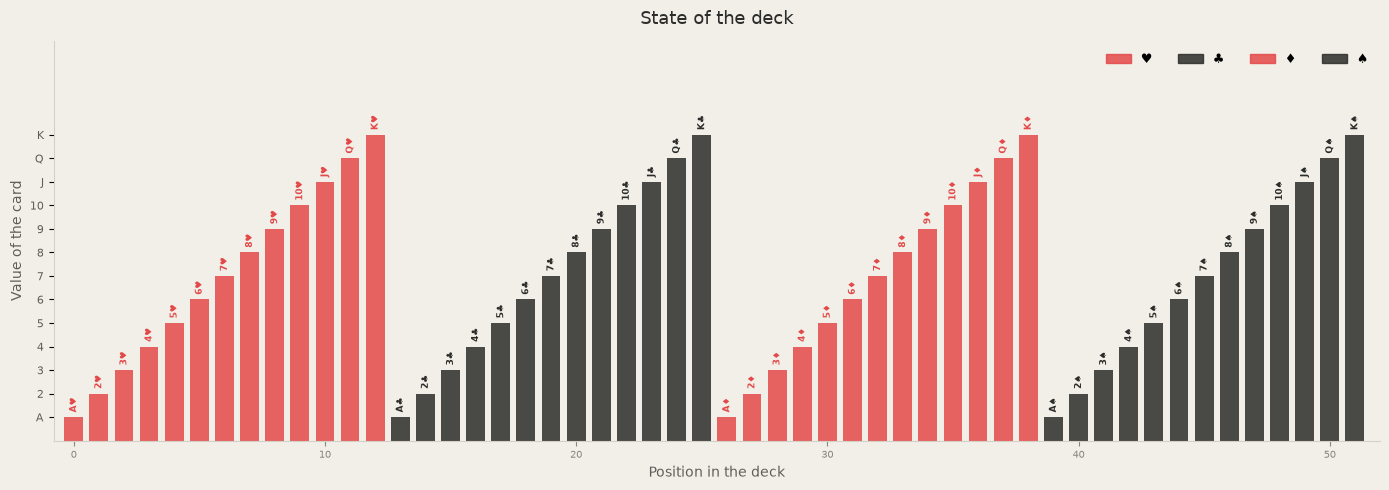

In [9]:
deck = Deck()
plot_deck(deck)

## 4) Different way to shuffle a deck

In [10]:
import random

def overhand_shuffle(deck: Deck, n_passes: int = 1, inplace: bool = False) -> Deck:
    """
    Overhand shuffle : at each pass, small packets are taken from the top
    and dropped one by one to build a new pile, reversing their order.
    The packet size follows a geometric distribution (parameter p).

    Deck: The deck to shuffle.
    n_passes: The number of passes to perform.
    inplace: Whether to modify the original deck.

    Returns:
        The shuffled deck.
    """
    # Probability of stopping the packet at each card → mean size ~1/p ≈ 7 cards
    p = 0.15

    # Working copy of the cards (we never modify the original deck)
    cards = deck.cards.copy()

    for _ in range(n_passes):

        result = []

        # remaining holds the cards not yet redistributed in this pass
        remaining = cards.copy()

        while remaining:

            # Draw a packet size from a geometric distribution:
            # we keep adding cards (size += 1) as long as random() > p,
            # meaning each card has probability p to be the last of the packet.
            # size starts at 0 but is guaranteed to reach at least 1
            size = 0
            while size == 0 or (size < len(remaining) and random.random() > p):
                size += 1

            # Split the top of the remaining pile into a packet
            packet    = remaining[:size]   # ← taken from the top
            remaining = remaining[size:]   # ← what is left underneath

            # Prepend the packet on top of the result pile
            # (last packet drawn ends up on top, as in a real overhand shuffle)
            result = packet + result

        # The result of this pass becomes the input of the next one
        cards = result

        if inplace:
            deck.cards = cards

    return Deck(cards=cards)

In [ ]:
deck = Deck()

overhand_shuffle(deck, n_passes=10, inplace=True)

Deck(52 cards, top card: Q♠)

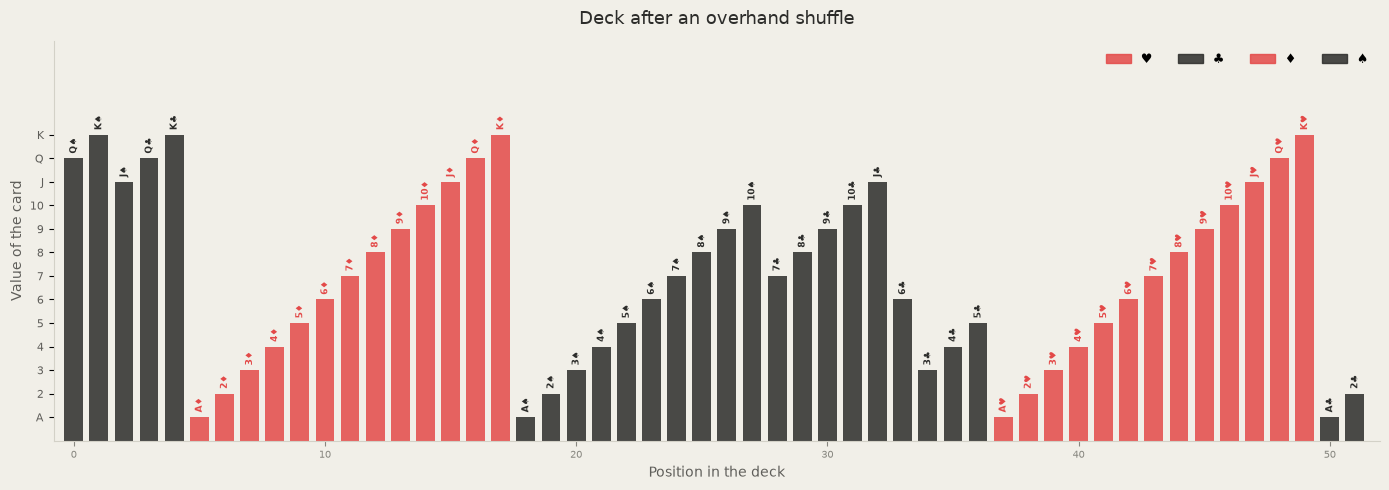

In [12]:
plot_deck(deck, title="Deck after an overhand shuffle")

In [13]:
entropy = position_entropy([deck], reference=Deck())

print(f"Mean Entropy : {entropy:.2f} bits (theorical max : {np.log2(52):.2f})")

Mean Entropy : 0.00 bits (theorical max : 5.70)
